# Cell 1: Setup and Imports
This cell links your notebook to the src folder and imports the plotting tools.

In [1]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt

# Link the notebook to the root project directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import src.plots as plots

# Define Parameters & Load NiTi

Here we will load the Nitinol (NiTi) material properties, set the beam radius to 40 µm, and apply your Absolute Zero ambient temperature.

In [7]:
# 1. Load NiTi Material Properties
mat_path = os.path.join('..', 'materials', 'NiTi.json')
with open(mat_path, 'r') as f:
    mat = json.load(f)

# Calculate thermal diffusivity if missing
if 'alpha' not in mat: 
    mat['alpha'] = mat['k'] / (mat['rho'] * mat['C_p'])

# 2. Define Laser Parameters
P_val = 250.0       # Laser Power (W)
v_val = 1.25         # Scan Speed (m/s)
a_val = 40e-6       # Beam Radius (40 microns)
T_amb = 0.0         # Absolute Zero (0 Kelvin)

print(f"Loaded Material: {mat.get('name', 'NiTi')}")
print(f"Melting Point: {mat['T_m']} K")
print(f"Parameters: P={P_val}W, v={v_val}m/s, T_ambient={T_amb}K")

Loaded Material: NiTi
Melting Point: 1583 K
Parameters: P=250.0W, v=1.25m/s, T_ambient=0.0K


# Plot the Eagar-Tsai Views

Let's generate the Top and Side views using the physical Eagar-Tsai model.

Generating Eagar-Tsai Plots...


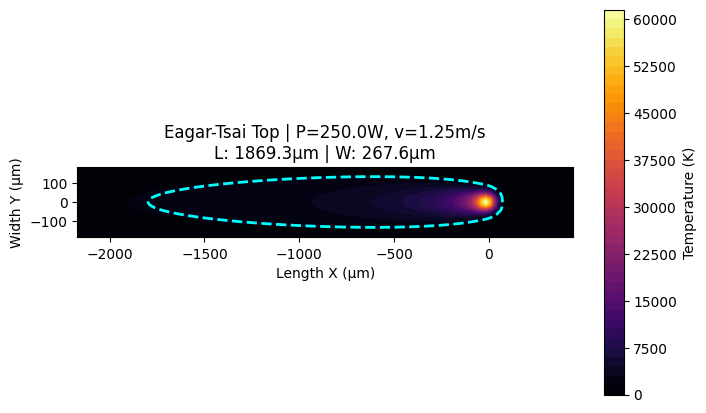

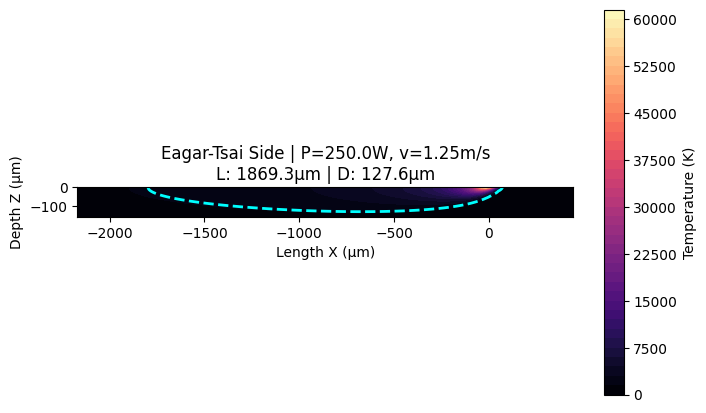

In [4]:
print("Generating Eagar-Tsai Plots...")

# Top View
fig_et_top = plots.top_view_eagar_tsai(
    P=P_val, v=v_val, a=a_val, 
    material=mat, T_ambient=T_amb, resolution=120
)

# Side View
fig_et_side = plots.side_view_eagar_tsai(
    P=P_val, v=v_val, a=a_val, 
    material=mat, T_ambient=T_amb, resolution=120
)

plt.show()

# Plot the Rubenchik Views

Now, let's generate the exact same plots using the dimensionless Rubenchik formulation. You should see the exact same Dimensions (L, W, D) printed in the titles of these plots as you saw in the Eagar-Tsai ones!

Generating Rubenchik Plots...


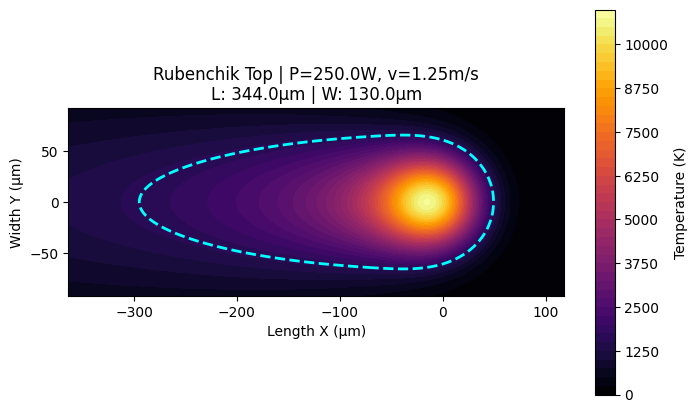

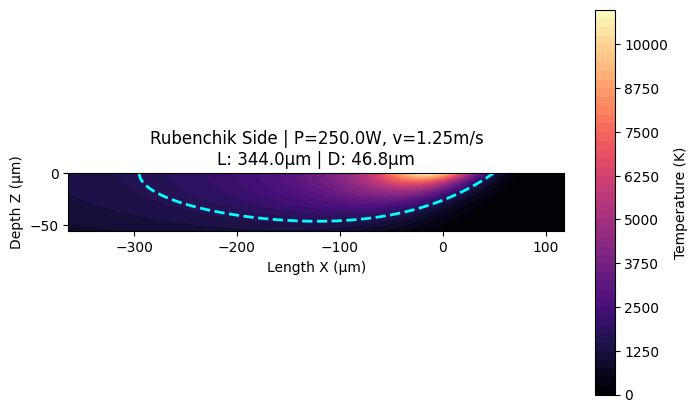

In [5]:
print("Generating Rubenchik Plots...")

# Top View
fig_rub_top = plots.top_view_rubenchik(
    P=P_val, v=v_val, a=a_val, 
    material=mat, T_ambient=T_amb, resolution=120
)

# Side View
fig_rub_side = plots.side_view_rubenchik(
    P=P_val, v=v_val, a=a_val, 
    material=mat, T_ambient=T_amb, resolution=120
)

plt.show()

# Generate the Master Grid Maps



Generating Eagar-Tsai Grid Maps (T_ambient = 0 K)...


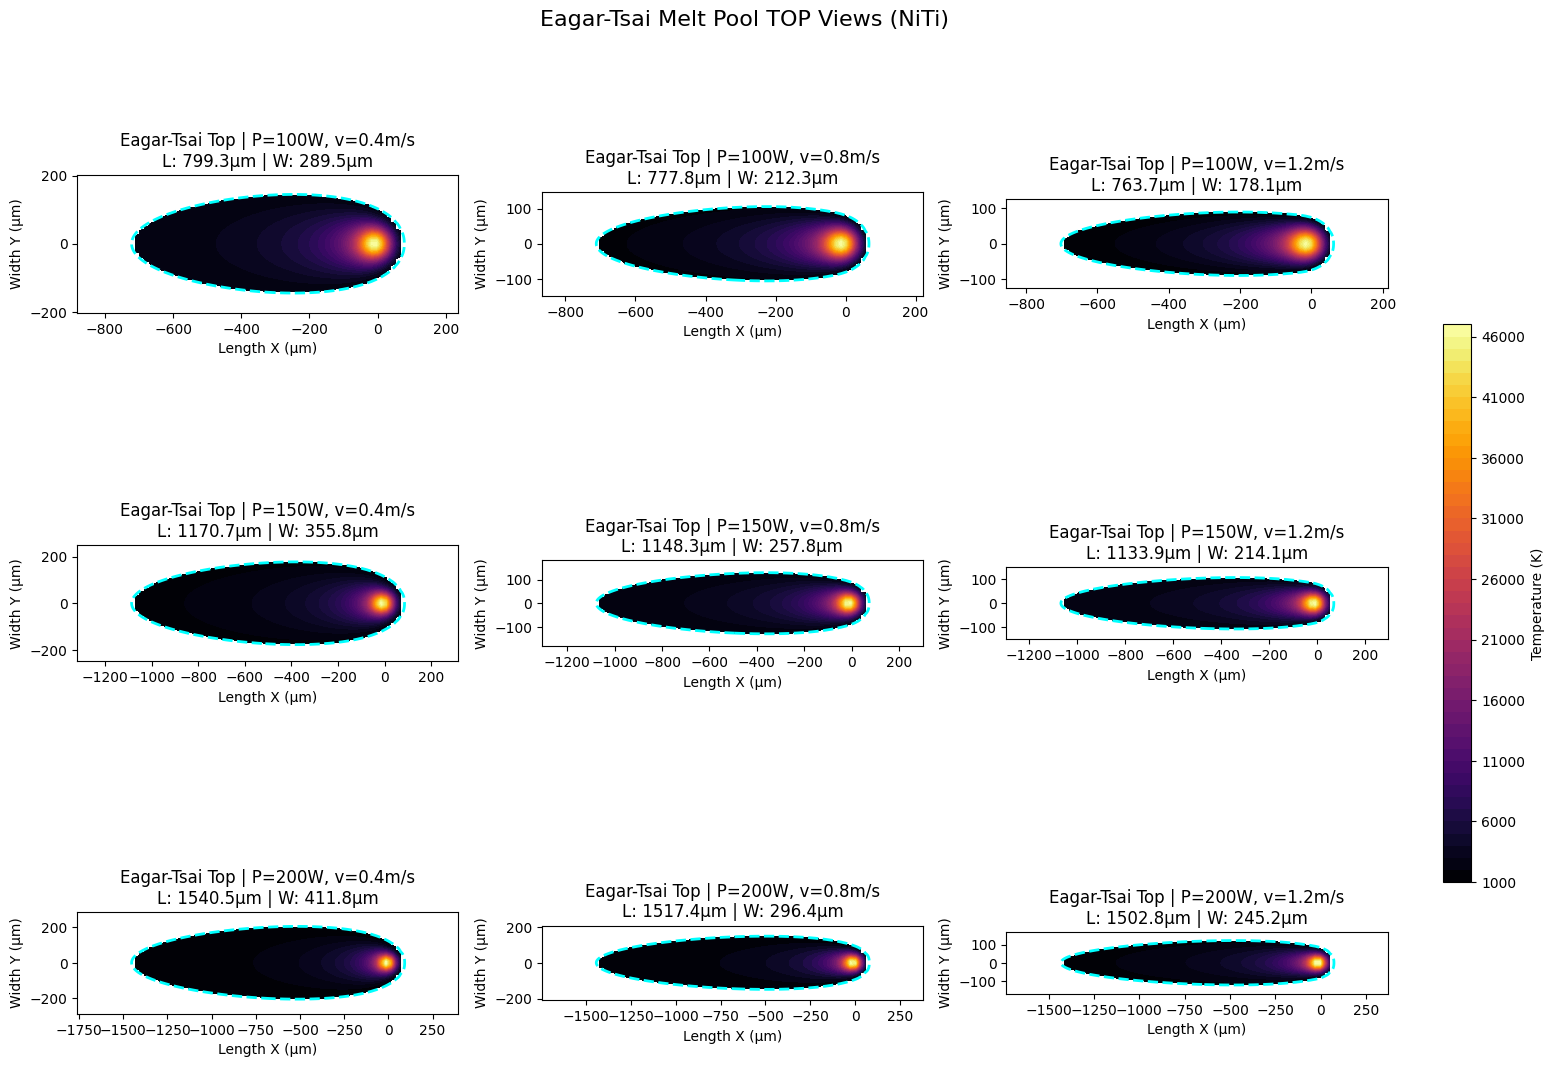

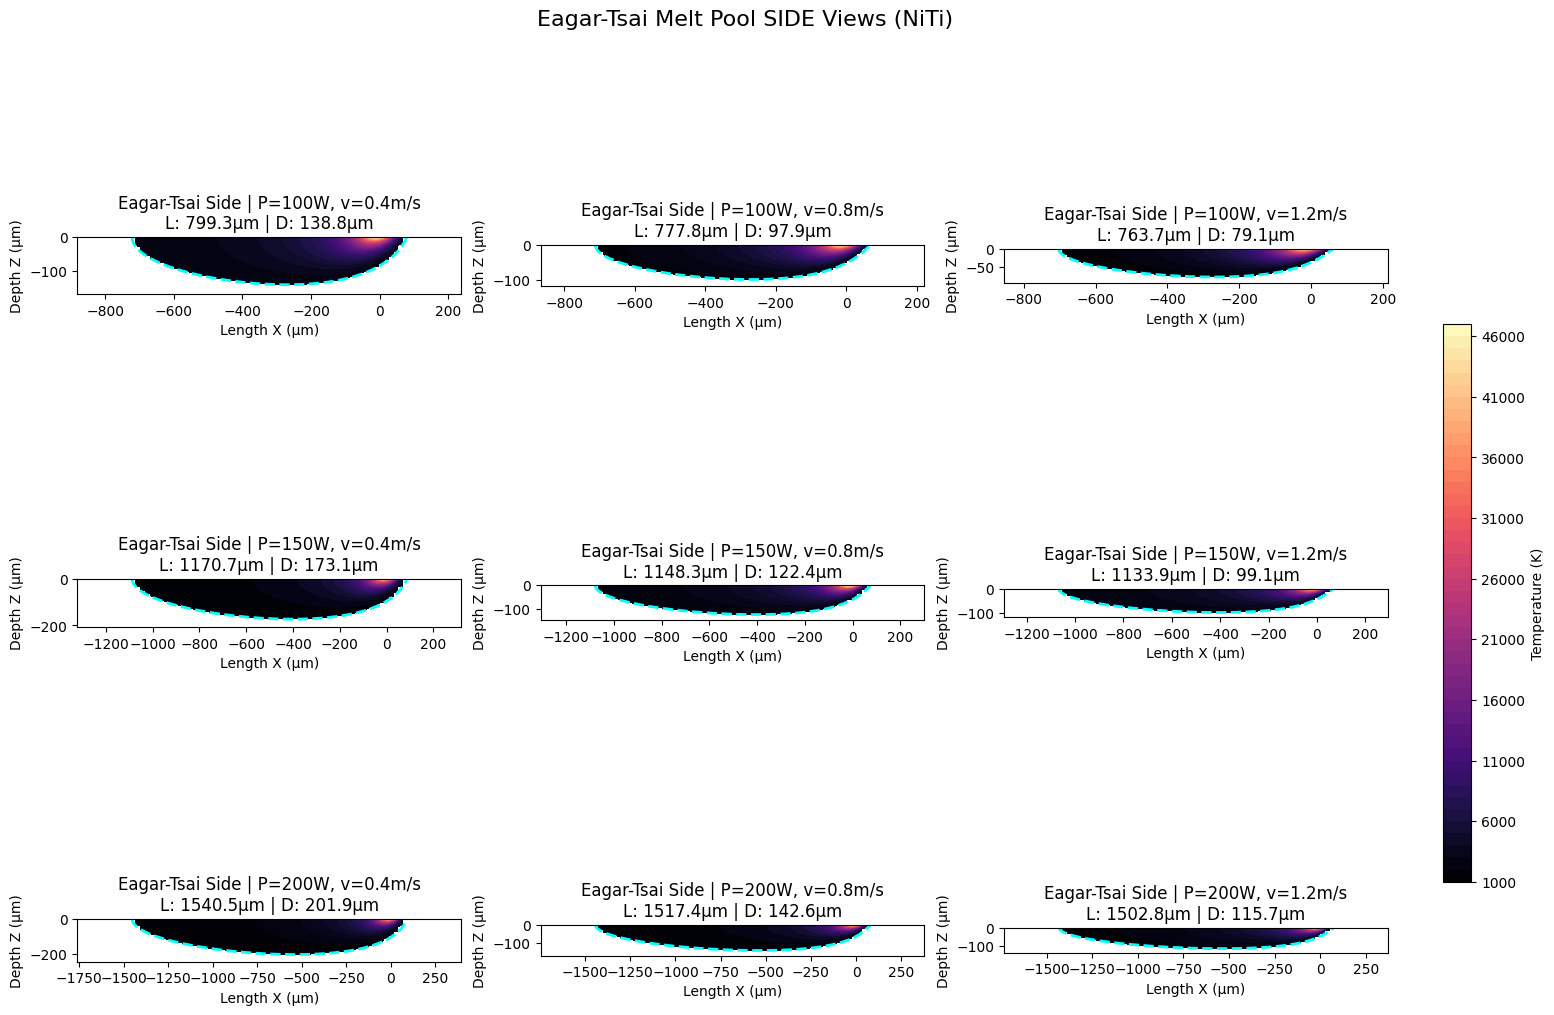

Generating Rubenchik Grid Maps (T_ambient = 0 K)...


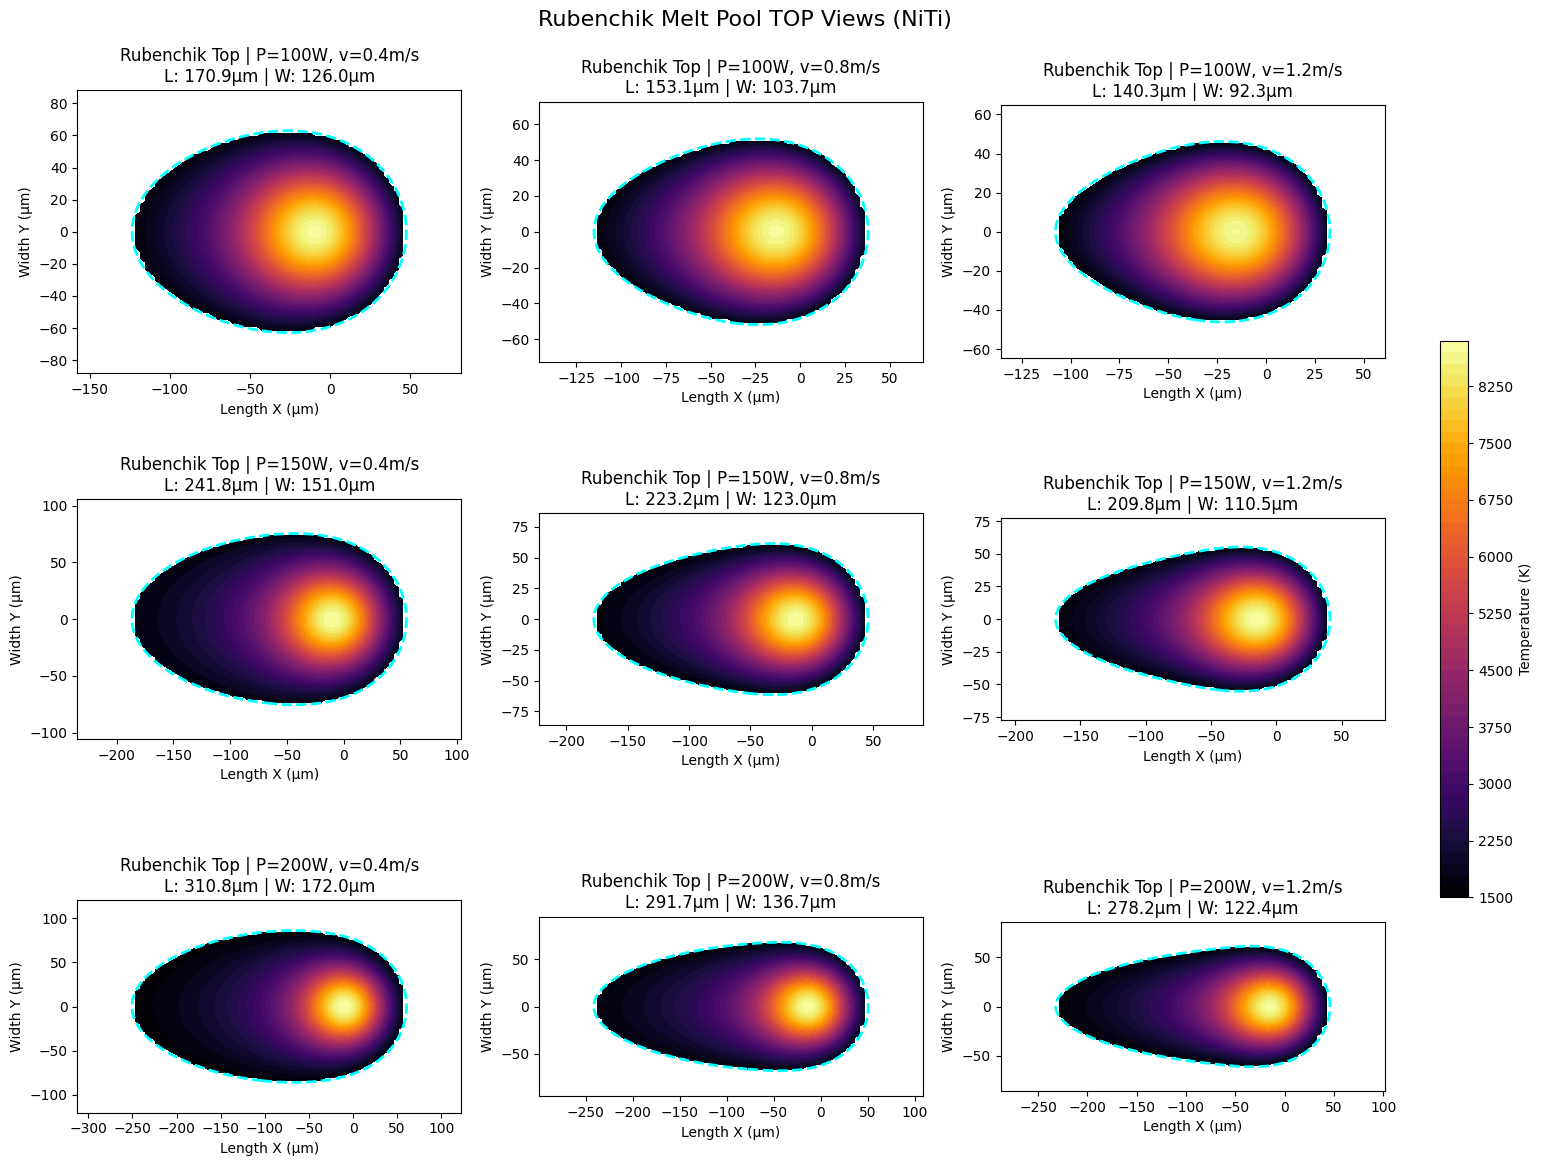

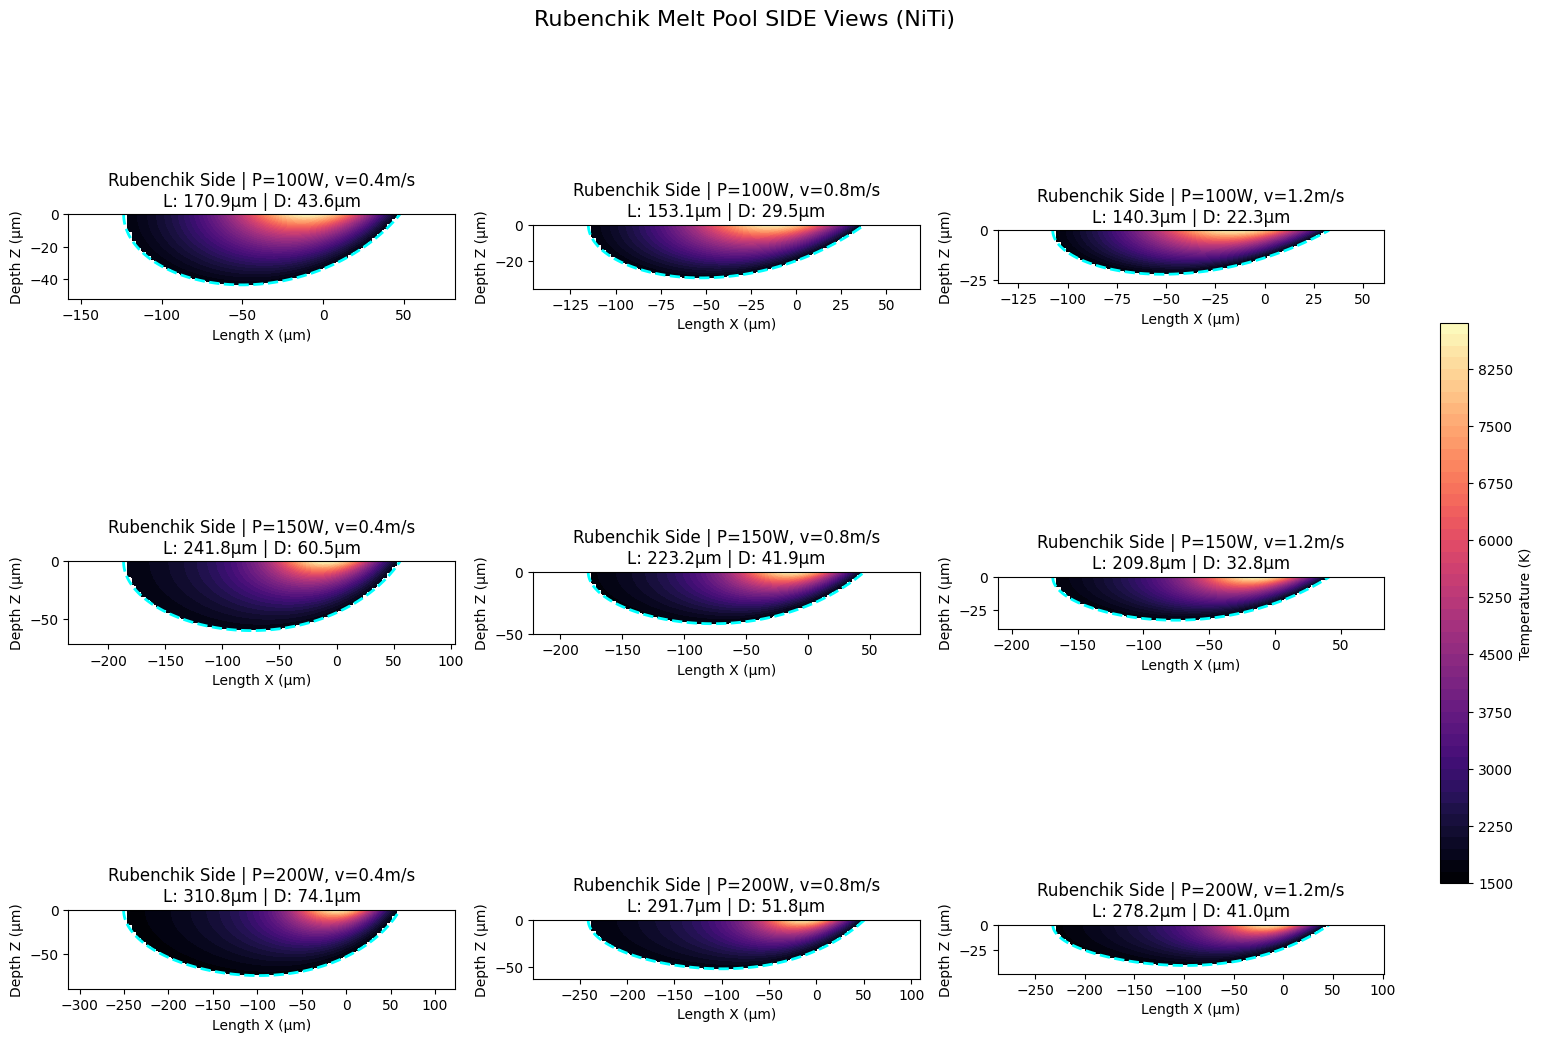

In [ ]:
# Define the matrix of parameters to sweep
P_list = [100, 150, 200]  # Laser Powers (W)
v_list = [0.4, 0.8, 1.2]  # Scan Speeds (m/s)

print("Generating Eagar-Tsai Grid Maps (T_ambient = 0 K)...")
fig_et_grid_top, fig_et_grid_side = plots.plot_process_eagar_tsai_grid_views(
    P_list=P_list, 
    v_list=v_list, 
    a=a_val, 
    material=mat, 
    T_ambient=T_amb
)
plt.show()

print("Generating Rubenchik Grid Maps (T_ambient = 0 K)...")
fig_rub_grid_top, fig_rub_grid_side = plots.plot_process_rubenchik_grid_views(
    P_list=P_list, 
    v_list=v_list, 
    a=a_val, 
    material=mat, 
    T_ambient=T_amb
)
plt.show()# Define the matrix of parameters to sweep
P_list = [100, 150, 200]  # Laser Powers (W)
v_list = [0.4, 0.8, 1.2]  # Scan Speeds (m/s)

print("Generating Eagar-Tsai Grid Maps (T_ambient = 0 K)...")
fig_et_grid_top, fig_et_grid_side = plots.plot_process_eagar_tsai_grid_views(
    P_list=P_list, 
    v_list=v_list, 
    a=a_val, 
    material=mat, 
    T_ambient=T_amb
)
plt.show()

print("Generating Rubenchik Grid Maps (T_ambient = 0 K)...")
fig_rub_grid_top, fig_rub_grid_side = plots.plot_process_rubenchik_grid_views(
    P_list=P_list, 
    v_list=v_list, 
    a=a_val, 
    material=mat, 
    T_ambient=T_amb
)
plt.show()